# 🤖 05 — AQI Prediction (Regression)

**Objective:** Predict AQI values using Random Forest and XGBoost regressors. Perform hyperparameter tuning with GridSearchCV. Analyze feature importance.

## 5.1 Feature Scaling — MinMax Normalization

In [48]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_normalize = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']
df_normalized = df.copy()
df_normalized[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])


## 5.2 Composite Pollution Score

Weighted combination of key pollutants:
- PM2.5: 35%, PM10: 20%, NO2: 15%, CO: 10%, SO2: 10%, O3: 10%

In [49]:
weights = {'PM2.5': 0.35, 'PM10': 0.20, 'NO2': 0.15, 
           'CO': 0.10, 'SO2': 0.10, 'O3': 0.10}

df_normalized['Composite_Score'] = sum(df_normalized[col]*weight for col,weight in weights.items())

In [50]:
df_normalized['Composite_Score'].describe()

count    29514.000000
mean         0.078918
std          0.044010
min          0.001606
25%          0.047786
50%          0.069456
75%          0.099073
max          0.588491
Name: Composite_Score, dtype: float64

In [51]:
df['AQI_Bucket'].value_counts()

AQI_Bucket
Moderate        10882
Satisfactory     9825
Poor             2781
Very Poor        2650
Severe           1996
Good             1380
Name: count, dtype: int64

## 5.3 Composite Score vs AQI — Validation

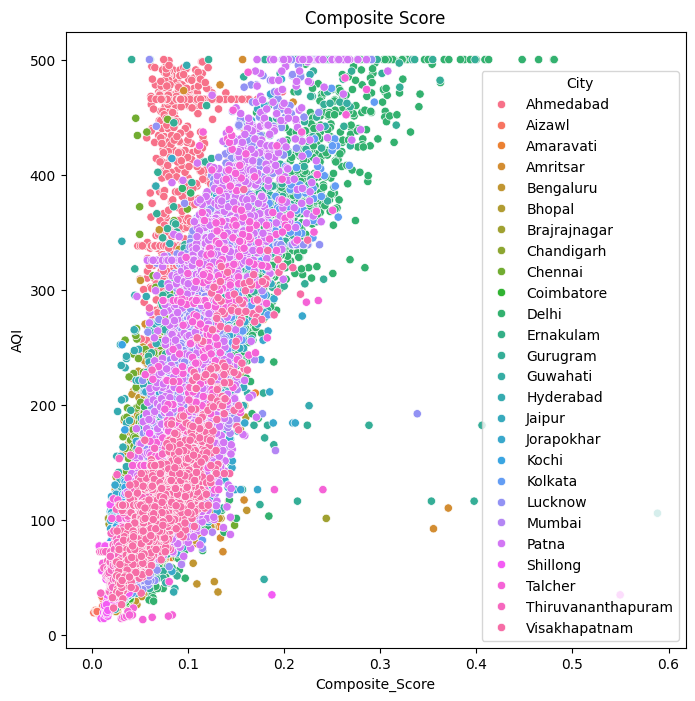

In [52]:
plt.figure(figsize=(8,8))
sns.scatterplot(df_normalized,x='Composite_Score',y='AQI',hue='City')
plt.title('Composite Score')
plt.show()

In [53]:
print(df_normalized[['Composite_Score','AQI']].corr())

                 Composite_Score       AQI
Composite_Score         1.000000  0.781846
AQI                     0.781846  1.000000


## 5.4 Encoding Categorical Features

In [54]:
from sklearn.preprocessing import LabelEncoder 

le = LabelEncoder()

df_normalized['Season_Encoded'] = le.fit_transform(df_normalized['Season'])

In [55]:
city_dummies = pd.get_dummies(df_normalized['City'],prefix = 'City')
df_normalized = pd.concat([df_normalized,city_dummies],axis=1)

In [56]:
df_normalized.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3',
       'Benzene', 'AQI', 'AQI_Bucket', 'Year', 'Month', 'Season',
       'Composite_Score', 'Season_Encoded', 'City_Ahmedabad', 'City_Aizawl',
       'City_Amaravati', 'City_Amritsar', 'City_Bengaluru', 'City_Bhopal',
       'City_Brajrajnagar', 'City_Chandigarh', 'City_Chennai',
       'City_Coimbatore', 'City_Delhi', 'City_Ernakulam', 'City_Gurugram',
       'City_Guwahati', 'City_Hyderabad', 'City_Jaipur', 'City_Jorapokhar',
       'City_Kochi', 'City_Kolkata', 'City_Lucknow', 'City_Mumbai',
       'City_Patna', 'City_Shillong', 'City_Talcher',
       'City_Thiruvananthapuram', 'City_Visakhapatnam'],
      dtype='object')

## 5.5 Train-Test Split

In [57]:
drop_cols =  ['AQI', 'AQI_Bucket', 'City', 'Season', 'Date', 'Month'] 
X = df_normalized.drop(columns=drop_cols)
y = df_normalized['AQI']

In [58]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

## 5.6 Model 1 — Random Forest Regressor

In [59]:
from sklearn.ensemble import RandomForestRegressor 
reg = RandomForestRegressor(n_estimators=100,random_state=42)

In [60]:
reg.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [61]:
y_pred = reg.predict(X_test)

In [62]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(mae, mse, rmse, r2)

16.68485541581442 891.470466015738 29.857502675470666 0.9216970124905047


## 5.7 Model 2 — XGBoost Regressor

In [63]:
from xgboost import XGBRegressor 
xgb_model = XGBRegressor(
    n_estimators = 320,
    learning_rate = 0.1,
    random_state = 42 
)

In [64]:
xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=320,
             n_jobs=None, num_parallel_tree=None, ...)

In [65]:
y_pred2 = xgb_model.predict(X_test)

In [66]:
mae = mean_absolute_error(y_test,y_pred2)
mse = mean_squared_error(y_test,y_pred2)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred2)

print(mae, mse, rmse, r2)

16.72871551331112 864.3307386860242 29.3995023543941 0.9240808511157006


## 5.8 Hyperparameter Tuning — GridSearchCV

In [67]:
from sklearn.model_selection import GridSearchCV 
param_grid = {
    'n_estimators' : [200,300,400,500],
    'learning_rate' : [0.07,0.1,0.15],
    'max_depth' : [3,5,6]
}

grid = GridSearchCV(
    estimator = xgb_model,
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2'
)

In [68]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=0.1, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=320,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.07, 0.1, 0.15],
                         'max_depth': [3, 5, 6],
                         'n_estimators': [200, 300, 400, 500]},
             scoring='r2')

In [69]:
print(param_grid)
print(grid.best_params_)
print(grid.best_score_)

{'n_estimators': [200, 300, 400, 500], 'learning_rate': [0.07, 0.1, 0.15], 'max_depth': [3, 5, 6]}
{'learning_rate': 0.07, 'max_depth': 6, 'n_estimators': 300}
0.9279553057496566


## 5.9 Feature Importance

In [70]:
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance':grid.best_estimator_.feature_importances_
})

In [71]:
feat_imp.sort_values(by='Importance',ascending=False)

,Feature,Importance
12,City_Ahmedabad,0.559772
0,PM2.5,0.177101
10,Composite_Score,0.047523
5,CO,0.035599
11,Season_Encoded,0.017585
22,City_Delhi,0.014676
1,PM10,0.013948
28,City_Jorapokhar,0.013449
2,NO,0.012519
13,City_Aizawl,0.010795


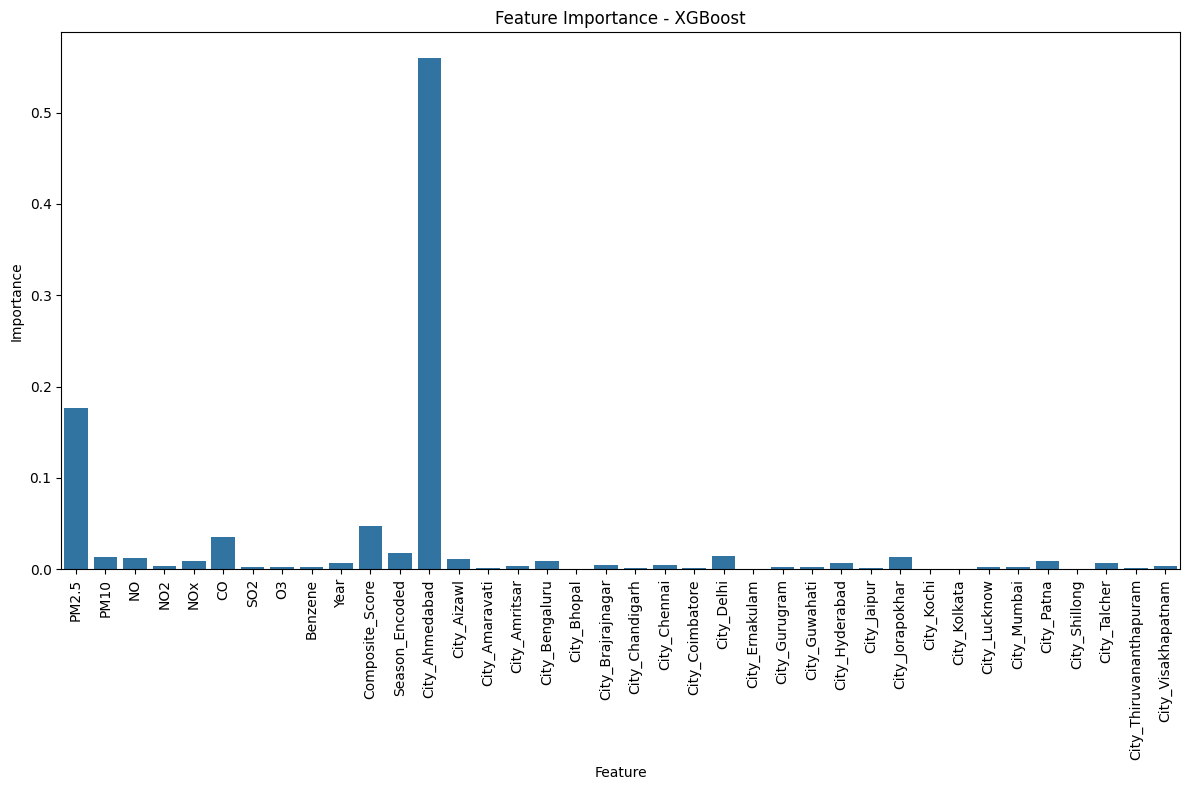

In [72]:
plt.figure(figsize=(12,8))
sns.barplot(data=feat_imp, x='Feature', y='Importance')
plt.xticks(rotation=90)
plt.title('Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

## 5.10 Actual vs Predicted AQI

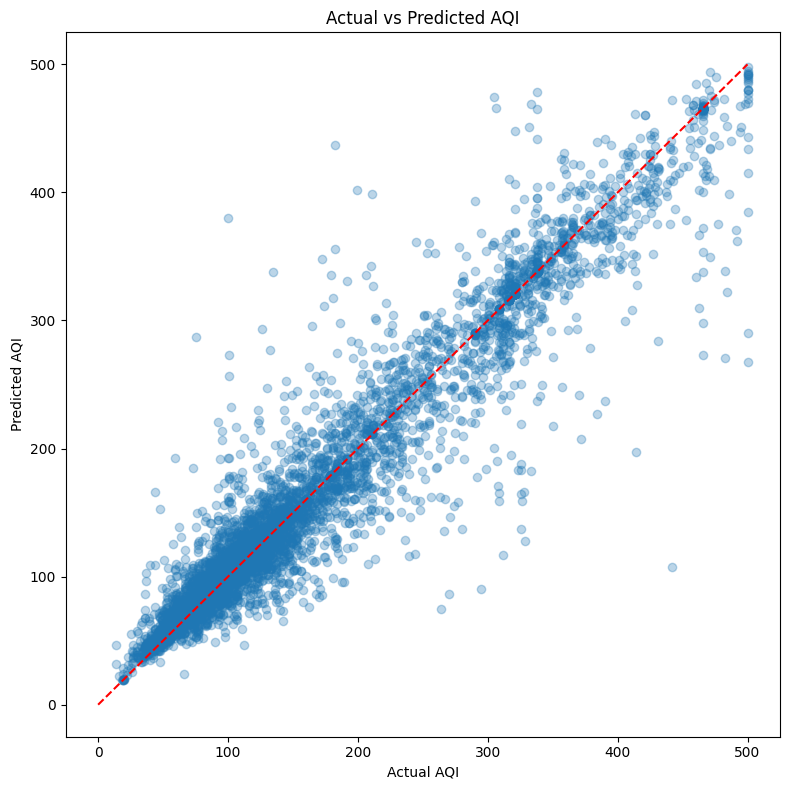

In [73]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, 500], [0, 500], 'r--')  # perfect prediction line
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI')
plt.tight_layout()
plt.show()